# Project B: Algorithmic Trading Strategy Simulation (15.458)

**Objective**: Implement, backtest, and analyze a contrarian long/short equity strategy using CRSP data.

## Data Requirements
- **Source**: SQL (crispy09 @ hedge.mit.edu) or CSV export
- **Universe**: Equities with `project b = 1` in dim_equity
- **In-sample**: 1/1/1992 to 12/31/1997
- **Out-of-sample (Part 4)**: 1998-2000, 2001-2003
- **Returns**: Log returns (continuously compounded), 252 trading days/year

In [1]:
# ========== Section 0: Setup and Data Loading ==========
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
# for 1(f) ACF: pip install statsmodels

# Constants
TRADING_DAYS = 252
SIM_START = '1992-01-01'
SIM_END = '1997-12-31'
OOS1_START, OOS1_END = '1998-01-01', '2000-12-31'
OOS2_START, OOS2_END = '2001-01-01', '2003-12-31'
pid = 'nikhibel'  # Kerberos ID

In [2]:
# Load data. Extended file includes OOS periods (1998-2003).
# Columns needed: date (d), stock id (id), return (ret)
DATA_PATH = 'full_legit_please_work.csv'

# CSV has: double-quoted fields, CRLF line endings, scientific notation in ret,
# empty strings in p_open/p_high/p_low (treated as NA). UTF-8 encoding.
df = pd.read_csv(
    DATA_PATH,
    encoding='utf-8',
    quotechar='"',
    doublequote=True,
    low_memory=False,  # avoid mixed-type warnings on large file
)
# Parse date and ensure correct dtypes
df['d'] = pd.to_datetime(df['d'])
df['id'] = df['id'].astype(int)
df['ret'] = pd.to_numeric(df['ret'], errors='coerce')
df = df.sort_values(['d', 'id']).reset_index(drop=True)

# Pivot to wide format: rows = dates, columns = stock ids
ret_wide = df.pivot(index='d', columns='id', values='ret')




# # For lag strategies, ensure we have enough history (e.g., k=5 needs 5 days before SIM_START)
# ret_wide = ret_wide.dropna(how='all')
# print(f"Returns matrix shape: {ret_wide.shape}")
# print(f"Date range: {ret_wide.index.min()} to {ret_wide.index.max()}")

## Sanity checking the data and handling missing/incorrect values 

We need to do a basic set of checks for the data including the following:
i. Do we have any NaN values 
ii. Do we have any returns that seem absurd/unlikely that we want to remove and normalize for 
iii. Do we have any impossible returns e.g., less than -1 is impossible 

In [ ]:
x = ret_wide.isna().sum()
values, keys = x.values, x.index
print(values, keys)

### Additional Data Quality Checks

Extended checks beyond the basic sanity checks above:

In [4]:
# 1. Duplicate rows: same (date, id) appearing more than once
dup_check = df.duplicated(subset=['d', 'id']).sum()
print("1. DUPLICATE ROWS (date, id):")
print(f"   Duplicate (d, id) pairs: {dup_check}")
if dup_check > 0:
    print(f"   Sample duplicates:\n{df[df.duplicated(subset=['d', 'id'], keep=False)].head(10)}")

1. DUPLICATE ROWS (date, id):
   Duplicate (d, id) pairs: 0


In [5]:
# 2. Date coverage: stocks per day (look for sudden drops/spikes)
stocks_per_day = ret_wide.notna().sum(axis=1)
print("2. DATE COVERAGE (stocks per day):")
print(f"   Min stocks/day: {stocks_per_day.min()}, Max: {stocks_per_day.max()}, Mean: {stocks_per_day.mean():.0f}")
if (stocks_per_day.diff().abs() > 100).any():
    spike_days = stocks_per_day.diff().abs()[stocks_per_day.diff().abs() > 100]
    print(f"   Days with >100 stock change: {len(spike_days)}")

2. DATE COVERAGE (stocks per day):
   Min stocks/day: 631, Max: 690, Mean: 684


In [6]:
# 3. Return bounds (log returns: flag extreme values)
ret_flat = ret_wide.values.flatten()
ret_valid = ret_flat[~np.isnan(ret_flat)]
impossible = (ret_valid < -1).sum()  # < -100% impossible for simple; suspicious for log
extreme = ((ret_valid > 0.5) | (ret_valid < -0.5)).sum()
print("3. RETURN BOUNDS:")
print(f"   Returns < -1 (impossible): {impossible}")
print(f"   Returns outside ±50% (extreme, flag for review): {extreme}")

3. RETURN BOUNDS:
   Returns < -1 (impossible): 5
   Returns outside ±50% (extreme, flag for review): 95


In [7]:
# 4. Zero returns: stocks with many consecutive zeros (possible stale data)
valid_count = ret_wide.notna().sum(axis=0)
zero_count = (ret_wide == 0).sum(axis=0)
zero_pct = zero_count / valid_count.replace(0, np.nan)
high_zero_stocks = (zero_pct > 0.5).fillna(False).sum()
print("4. ZERO RETURNS (potential stale data):")
print(f"   Stocks with >50% zero returns: {int(high_zero_stocks)}")

4. ZERO RETURNS (potential stale data):
   Stocks with >50% zero returns: 0


In [8]:
# 5. Identical returns: days where many stocks have same return (data copy error)
same_ret_days = []
for d in ret_wide.index[:500]:  # sample first 500 days for speed
    row = ret_wide.loc[d].dropna()
    if len(row) > 10:
        mode_count = row.value_counts().iloc[0]
        if mode_count > len(row) * 0.3:  # >30% same value
            same_ret_days.append(d)
print("5. IDENTICAL RETURNS (potential data error):")
print(f"   Days with >30% identical returns (sample): {len(same_ret_days)}")

5. IDENTICAL RETURNS (potential data error):
   Days with >30% identical returns (sample): 0


In [9]:
# 6. NaN summary by column and by date
print("6. NaN SUMMARY:")
print(f"   Total NaN in ret_wide: {ret_wide.isna().sum().sum()}")
print(f"   NaN by date (max): {ret_wide.isna().sum(axis=1).max()} per day")

6. NaN SUMMARY:
   Total NaN in ret_wide: 17775
   NaN by date (max): 59 per day


In [10]:
# 7. Volume consistency (if available)
if 'volume' in df.columns:
    zero_vol_nonzero_ret = ((df['volume'] == 0) | (df['volume'].isna())) & (df['ret'].notna()) & (df['ret'] != 0)
    print("7. VOLUME CONSISTENCY:")
    print(f"   Rows with zero/missing volume but non-zero return: {zero_vol_nonzero_ret.sum()}")
else:
    print("7. VOLUME CONSISTENCY: (volume column not in df, skipping)")

7. VOLUME CONSISTENCY:
   Rows with zero/missing volume but non-zero return: 36542


In [11]:
# 8. Price validity (if available)
if 'p' in df.columns:
    bad_price = (df['p'] <= 0) | (df['p'].isna())
    print("8. PRICE VALIDITY:")
    print(f"   Rows with non-positive or missing price: {bad_price.sum()}")
else:
    print("8. PRICE VALIDITY: (p column not in df, skipping)")

8. PRICE VALIDITY:
   Rows with non-positive or missing price: 17775


In [12]:
# 9. Cross-sectional dispersion: unusually high/low variance days
daily_std = ret_wide.std(axis=1)
print("9. CROSS-SECTIONAL DISPERSION:")
print(f"   Daily return std: min={daily_std.min():.4f}, max={daily_std.max():.4f}, median={daily_std.median():.4f}")
extreme_std_days = daily_std[daily_std > daily_std.quantile(0.99)]
print(f"   Days in top 1% dispersion: {len(extreme_std_days)}")

9. CROSS-SECTIONAL DISPERSION:
   Daily return std: min=0.0149, max=0.0819, median=0.0254
   Days in top 1% dispersion: 31


### Data Cleaning and Fixes

Apply corrections based on quality checks. Cleaned data used for strategy.

In [13]:
# Create cleaned copy; apply fixes before pivot
df_clean = df.copy()

# Fix 1: Drop duplicate (d, id) - keep first occurrence
df_clean = df_clean.drop_duplicates(subset=['d', 'id'], keep='first')

# Fix 2: Replace impossible returns (ret < -1) with NaN
# Log returns < -1 imply >63% loss in one day - data error for CRSP
df_clean.loc[df_clean['ret'] < -1, 'ret'] = np.nan

# Fix 3: Winsorize extreme returns at ±50% (optional, reduces outlier impact)
# Log return ±0.5 ≈ ±65% simple return - cap for robustness
df_clean['ret'] = df_clean['ret'].clip(lower=-0.5, upper=0.5)

# Rebuild ret_wide from cleaned df
ret_wide = df_clean.pivot(index='d', columns='id', values='ret')

print(f"Cleaned: {len(df) - len(df_clean)} duplicates dropped")
print(f"Returns matrix shape: {ret_wide.shape}")

Cleaned: 0 duplicates dropped
Returns matrix shape: (3032, 690)


---
## Part 1: Strategy Simulation

**Formulas:**
- Market return: $R(t) = \frac{1}{N}\sum_i R_i(t)$
- Raw weights: $w_i^{raw}(t) \propto -(R_i(t) - R(t))$
- Normalization (Eq. 4): $\sum_{i \in L} w_i = 1$, $\sum_{j \in S} |w_j| = 1$
- Portfolio return: $\pi(t) = \sum_i w_i(t-1) R_i(t)$

In [14]:
def compute_market_return(ret_df):
    """R(t) = equal-weighted average of all stocks"""
    return ret_df.mean(axis=1)

def compute_raw_weights(excess_returns):
    """w_i raw ∝ -(R_i - R). Returns DataFrame same shape as excess_returns."""
    return -excess_returns

def normalize_weights_long_short(w_raw):
    """
    Scale so sum(long) = 1 and sum(abs(short)) = 1.
    w_raw: Series or row of excess returns (positive = long, negative = short)
    """
    w = w_raw.copy()
    longs = w > 0
    shorts = w < 0
    if longs.sum() > 0:
        w[longs] = w[longs] / w[longs].sum()
    if shorts.sum() > 0:
        w[shorts] = w[shorts] / w[shorts].abs().sum()
    return w

def contrarian_weights_at_t(ret_row, market_ret):
    """Weights for one day: raw then normalized (Eq. 2, 4)."""
    excess = ret_row - market_ret
    excess = excess.fillna(0)  # Exclude stocks with NaN return from portfolio (0 weight)
    w_raw = compute_raw_weights(excess)
    return normalize_weights_long_short(w_raw)

def compute_portfolio_returns(ret_wide, weights_df):
    """π(t) = sum_i w_i(t-1) * R_i(t). Align by shifting weights."""
    # weights_df index = dates when weights are set; ret_wide = next-day returns
    pi = (weights_df.shift(1) * ret_wide).sum(axis=1)
    return pi.dropna()

In [15]:
# Compute strategy for in-sample period (k=1, lag-1 contrarian)
mask = (ret_wide.index >= SIM_START) & (ret_wide.index <= SIM_END)
ret_insample = ret_wide.loc[mask].copy()

R_mkt = compute_market_return(ret_insample)
weights_list = []
for t in ret_insample.index:
    w = contrarian_weights_at_t(ret_insample.loc[t], R_mkt.loc[t])
    weights_list.append(w)
weights_k1 = pd.DataFrame(weights_list, index=ret_insample.index, columns=ret_insample.columns)

pi_strategy = compute_portfolio_returns(ret_insample, weights_k1)
R_mkt_aligned = R_mkt.loc[pi_strategy.index]

### 1(a) Plot daily portfolio returns π(t) and market returns R(t)

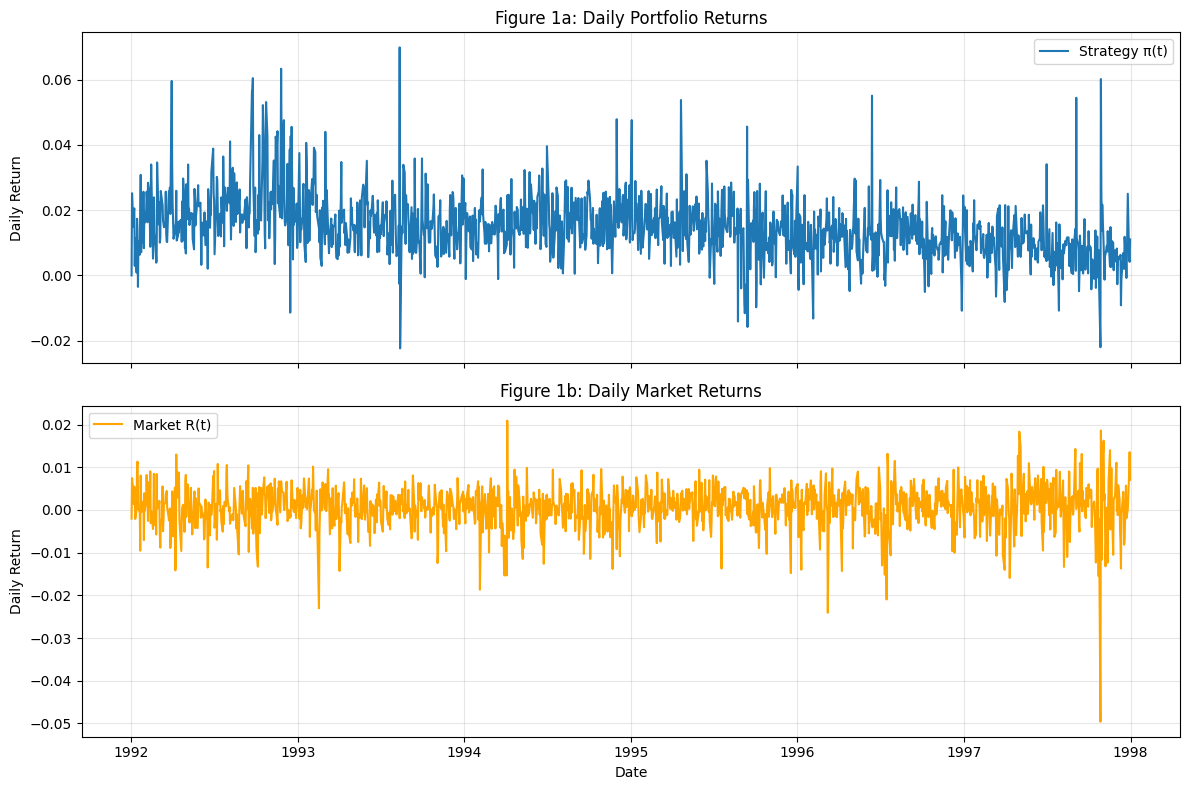

In [16]:
# TODO: Create two labeled plots (or subplots)
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
axes[0].plot(pi_strategy.index, pi_strategy.values, label='Strategy π(t)')
axes[0].set_ylabel('Daily Return')
axes[0].set_title('Figure 1a: Daily Portfolio Returns')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(R_mkt_aligned.index, R_mkt_aligned.values, color='orange', label='Market R(t)')
axes[1].set_ylabel('Daily Return')
axes[1].set_xlabel('Date')
axes[1].set_title('Figure 1b: Daily Market Returns')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 1(b) Annualized mean return, volatility, Sharpe ratio (strategy vs market)

In [17]:
# TODO: Annualize: mean*252, vol*sqrt(252). Sharpe ≈ mean/vol (rf=0). Report 2-3 sigfigs.
def annualize_stats(daily_ret):
    mu = daily_ret.mean() * TRADING_DAYS
    vol = daily_ret.std() * np.sqrt(TRADING_DAYS)
    sharpe = mu / vol if vol > 0 else np.nan
    return mu, vol, sharpe

mu_pi, vol_pi, sharpe_pi = annualize_stats(pi_strategy)
mu_R, vol_R, sharpe_R = annualize_stats(R_mkt_aligned)

print("Strategy:  Mean {:.2%}  Vol {:.2%}  Sharpe {:.2f}".format(mu_pi, vol_pi, sharpe_pi))
print("Market:    Mean {:.2%}  Vol {:.2%}  Sharpe {:.2f}".format(mu_R, vol_R, sharpe_R))

Strategy:  Mean 372.01%  Vol 15.26%  Sharpe 24.38
Market:    Mean 14.77%  Vol 7.80%  Sharpe 1.89


### 1(c) Consistency over time? Stationarity of strategy returns?

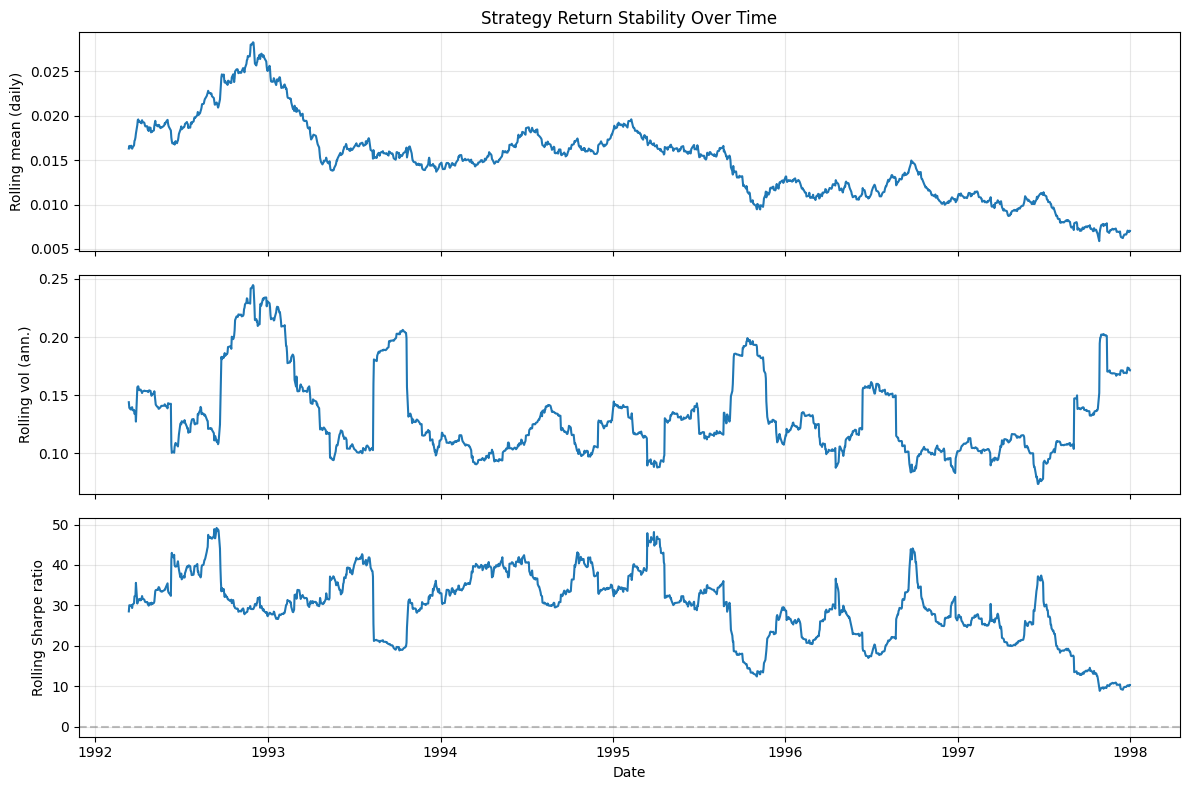

Early half: mean 451.6411%, vol 15.2395%
Late half:  mean 292.3887%, vol 13.5446%

ADF test for stationarity (daily strategy returns):
  ADF statistic: -2.9969
  p-value: 0.0352
  Critical values: {'1%': -3.4347287139577753, '5%': -2.8634739225299133, '10%': -2.5677995973755325}
  Conclusion: Reject H0 → series appears stationary


In [32]:
# TODO: Rolling mean/vol, subsample stats, or formal stationarity test
# Hint: Split sample into halves or rolling windows; compare mean/vol
window = 50  # 1 year
rolling_mean = pi_strategy.rolling(window).mean()
rolling_vol = pi_strategy.rolling(window).std() * np.sqrt(TRADING_DAYS)
rolling_mean_ann = rolling_mean * TRADING_DAYS
rolling_sr = rolling_mean_ann / rolling_vol  # annualized SR over rolling window

fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
axes[0].plot(rolling_mean.index, rolling_mean.values)
axes[0].set_ylabel('Rolling mean (daily)')
axes[0].set_title('Strategy Return Stability Over Time')
axes[0].grid(True, alpha=0.3)
axes[1].plot(rolling_vol.index, rolling_vol.values)
axes[1].set_ylabel('Rolling vol (ann.)')
axes[1].grid(True, alpha=0.3)
axes[2].plot(rolling_sr.index, rolling_sr.values)
axes[2].set_ylabel('Rolling Sharpe ratio')
axes[2].set_xlabel('Date')
axes[2].axhline(y=0, color='gray', linestyle='--', alpha=0.5)
axes[2].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Subsample comparison: TODO fill in interpretation
half = len(pi_strategy) // 2
early, late = pi_strategy.iloc[:half], pi_strategy.iloc[half:]
print("Early half: mean {:.4%}, vol {:.4%}".format(early.mean()*252, early.std()*np.sqrt(252)))
print("Late half:  mean {:.4%}, vol {:.4%}".format(late.mean()*252, late.std()*np.sqrt(252)))

# Augmented Dickey-Fuller test for stationarity of daily returns
from statsmodels.tsa.stattools import adfuller
adf_result = adfuller(pi_strategy.dropna(), autolag='AIC')
print("\nADF test for stationarity (daily strategy returns):")
print(f"  ADF statistic: {adf_result[0]:.4f}")
print(f"  p-value: {adf_result[1]:.4f}")
print(f"  Critical values: {adf_result[4]}")
if adf_result[1] < 0.05:
    print("  Conclusion: Reject H0 → series appears stationary")
else:
    print("  Conclusion: Fail to reject H0 → series may have unit root (non-stationary)")

### 1(d) Unusual events (days)? Stock outliers? Effect on strategy?

In [19]:
# TODO: Flag unusual days (z-score > 3?), stock-level outliers, robustness check
z_scores = np.abs(stats.zscore(pi_strategy.dropna()))
unusual_days = pi_strategy.index[z_scores > 4]

print(unusual_days)

DatetimeIndex(['1992-03-30', '1992-09-22', '1992-09-23', '1992-09-24',
               '1992-11-25', '1993-08-12', '1995-04-21', '1996-06-13',
               '1997-09-04', '1997-10-28'],
              dtype='datetime64[ns]', name='d', freq=None)


In [20]:
for day in unusual_days:
    print(day, pi_strategy[day])

1992-03-30 00:00:00 0.05958043570257858
1992-09-22 00:00:00 0.0562233803238459
1992-09-23 00:00:00 0.05705610364961703
1992-09-24 00:00:00 0.06043770160134291
1992-11-25 00:00:00 0.06331699815016703
1993-08-12 00:00:00 0.06985614395914883
1995-04-21 00:00:00 0.05373653563268265
1996-06-13 00:00:00 0.055058347860486
1997-09-04 00:00:00 0.054416074000843036
1997-10-28 00:00:00 0.06016079633521878


### 1(e) Correlation between strategy and market. Market-neutral or dollar-neutral?

In [21]:
# TODO: Compute correlation; interpret
corr = np.corrcoef(pi_strategy.dropna(), R_mkt_aligned.reindex(pi_strategy.index).dropna())[0, 1]
print("Correlation(π, R_market) = {:.4f}".format(corr))
# Dollar-neutral: long+short weights sum to 0. Market-neutral: low correlation with market.

Correlation(π, R_market) = 0.0565


### 1(f) Autocorrelation of strategy returns?

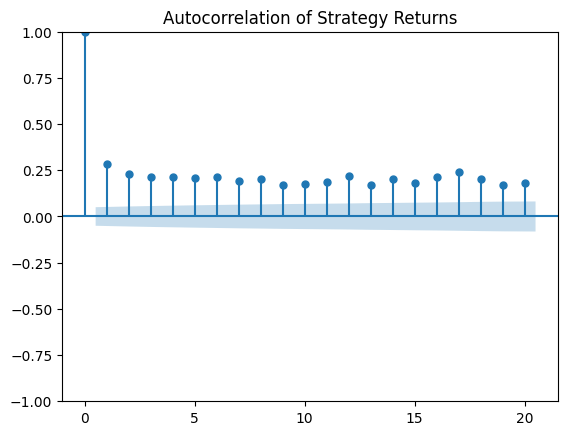

In [22]:
# TODO: ACF plot; interpret (e.g., momentum vs mean-reversion implications)
from statsmodels.graphics.tsaplots import plot_acf
plot_acf(pi_strategy.dropna(), lags=20)
plt.title('Autocorrelation of Strategy Returns')
plt.show()

### 1(g) Maximum drawdown (peak-to-trough decline in cumulative return)

In [23]:
# TODO: Cumulative return, then max drawdown = max(peak - trough) over running peak
cumret = (1 + pi_strategy).cumprod()
running_max = cumret.expanding().max()
drawdown = (cumret - running_max) / running_max
max_dd = drawdown.min()
print("Maximum drawdown: {:.2%}".format(max_dd))

Maximum drawdown: -2.85%


### 1(h) Correlation between long and short sub-portfolio returns

In [24]:
# Long leg: sum over w>0 of w(t-1)*R(t); short leg: sum over w<0 of w(t-1)*R(t)
w_prev = weights_k1.shift(1)
ret_long = (w_prev.clip(lower=0) * ret_insample).sum(axis=1).dropna()
ret_short = (w_prev.clip(upper=0) * ret_insample).sum(axis=1).dropna()
common_idx = ret_long.index.intersection(ret_short.index)
corr_ls = np.corrcoef(ret_long.loc[common_idx], ret_short.loc[common_idx])[0, 1]
print("Correlation(long leg, short leg) = {:.4f}".format(corr_ls))

Correlation(long leg, short leg) = -0.3156


### 1(i) Realism, implementability, data issues

*Discussion cell. Consider: transaction costs, market impact, slippage, survivorship bias, look-ahead bias, data quality.*

In [25]:
# Sum of all daily returns in Part 1
sum_daily_returns = pi_strategy.sum()
print(f"Sum of all daily returns: {sum_daily_returns:.6f}")

Sum of all daily returns: 22.409467


---
## Part 2: A Family of Strategies (Lag k)

Weights: $w_i^{(k)}(t-1) \propto -(R_i(t-k) - R(t-k))$ for k = 1, 2, 3, 4, 5

In [33]:
def weights_for_lag_k(ret_wide, k):
    """Compute normalized weights using lag-k excess returns. Returns DataFrame."""
    R_mkt = ret_wide.mean(axis=1)
    excess = ret_wide.sub(R_mkt, axis=0)
    excess_lag = excess.shift(k-1).fillna(0)  # R_i(t-k) - R(t-k); NaN -> 0 weight
    w_list = []
    for t in ret_wide.index:
        w = normalize_weights_long_short(-excess_lag.loc[t])
        w_list.append(w)
    return pd.DataFrame(w_list, index=ret_wide.index, columns=ret_wide.columns)

### 2(a) Table: Annualized mean, vol, Sharpe for k = 1, 2, 3, 4, 5

In [34]:
# TODO: Loop k=1..5; compute metrics; build table; discuss optimal k
results = []
for k in range(1, 6):
    w_k = weights_for_lag_k(ret_insample, k)
    pi_k = compute_portfolio_returns(ret_insample, w_k)
    mu, vol, sh = annualize_stats(pi_k)
    results.append({'k': k, 'Mean': mu, 'Vol': vol, 'Sharpe': sh})
df_results = pd.DataFrame(results)
print(df_results.to_string(index=False))

 k     Mean      Vol    Sharpe
 1 3.720149 0.152607 24.377313
 2 0.291023 0.113532  2.563350
 3 0.182813 0.110439  1.655324
 4 0.130150 0.105328  1.235665
 5 0.049623 0.103730  0.478388


### 2(b) Flat file for upload: pid, d, id, k, w, vid

Format: Column 1=pid, 2=d, 3=id, 4=k, 5=w, 6=vid (0). No zeros, NaNs, duplicates.

In [28]:
# TODO: Build upload file. Rows: (pid, date, stock_id, k, weight, vid=0) for each (date, id, k)
# Exclude zero weights. Ensure no NaNs or duplicates.
rows = []
for k in range(1, 6):
    w_k = weights_for_lag_k(ret_insample, k)
    for d in w_k.index:
        for sid in w_k.columns:
            w = w_k.loc[d, sid]
            if w != 0 and not np.isnan(w):
                rows.append({'pid': pid, 'd': d.strftime('%Y-%m-%d'), 'id': int(sid), 'k': k, 'w': w, 'vid': 0})
upload_df = pd.DataFrame(rows)
upload_df.to_csv('portfolio_weights_upload.csv', index=False)
print(f"Rows: {len(upload_df)}")

Rows: 5222415


### 2(c)-(e) Upload to upload.dbo.ProjectB; validate; use vid=1 for fixes

---
## Part 3: Strategy R&D

**Custom strategy**: Power-weighted contrarian. Weights ∝ -sign(excess) × |excess|^power — the further from the market, the larger the position. power=1 is linear (baseline); power>1 overweights extreme movers. Toggle `POWER` to experiment.

Custom (power=2): Mean 62.59%  Vol 40.41%  Sharpe 1.55
Baseline (k=1):   Mean 372.01%  Vol 15.26%  Sharpe 24.38

Grid search (power):
 power     Mean      Vol   Sharpe
   0.5 0.184926 0.059759 3.094538
   1.0 0.291023 0.113532 2.563350
   1.5 0.440117 0.227825 1.931819
   2.0 0.625900 0.404119 1.548802
   2.5 0.817608 0.598549 1.365983
   3.0 0.990947 0.773904 1.280452
   3.5 1.140220 0.918976 1.240751
   4.0 1.267652 1.035398 1.224314

Best power = 0.50 (Sharpe 3.09)


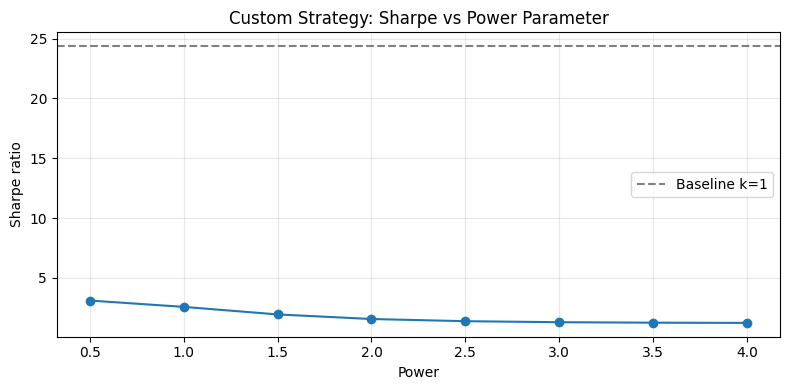

In [29]:
# Custom strategy: power-weighted — further from market => larger weight
# w ∝ -sign(excess) * |excess|^power  (power=1: linear, power=2: quadratic, power=3: cubic)
POWER = 2  # Toggle: 1=linear, 2=quadratic, 3=cubic — higher = more concentration on extremes

def custom_strategy_weights(excess, power=1.3):
    """
    Raw weight ∝ -sign(excess) * |excess|^power. Preserves direction (long losers, short winners)
    but scales magnitude: larger |excess| => larger position.
    """
    ex = excess.fillna(0)
    raw = -np.sign(ex) * (np.abs(ex) ** power)
    return normalize_weights_long_short(raw)

# Loop over days with lag-1 excess; compute custom weights and returns
excess_lag1 = ret_insample.sub(ret_insample.mean(axis=1), axis=0).shift(1)
custom_weights_list = []
for t in ret_insample.index:
    ex = excess_lag1.loc[t]
    w = custom_strategy_weights(ex, power=POWER)
    custom_weights_list.append(w)
weights_custom = pd.DataFrame(custom_weights_list, index=ret_insample.index, columns=ret_insample.columns)
pi_custom = compute_portfolio_returns(ret_insample, weights_custom)
mu_c, vol_c, sh_c = annualize_stats(pi_custom)
print("Custom (power={}): Mean {:.2%}  Vol {:.2%}  Sharpe {:.2f}".format(POWER, mu_c, vol_c, sh_c))
print("Baseline (k=1):   Mean {:.2%}  Vol {:.2%}  Sharpe {:.2f}".format(mu_pi, vol_pi, sharpe_pi))

# Grid search over power
POWER_GRID = np.linspace(0.5, 4, 8)  # Toggle: e.g. [1, 1.5, 2, 2.5, 3] or np.arange(1, 4.5, 0.5)
grid_results = []
for p in POWER_GRID:
    w_p = pd.DataFrame([custom_strategy_weights(excess_lag1.loc[t], power=p) for t in ret_insample.index],
                       index=ret_insample.index, columns=ret_insample.columns)
    pi_p = compute_portfolio_returns(ret_insample, w_p)
    mu, vol, sh = annualize_stats(pi_p)
    grid_results.append({'power': round(p, 2), 'Mean': mu, 'Vol': vol, 'Sharpe': sh})
df_grid = pd.DataFrame(grid_results)
best_idx = df_grid['Sharpe'].idxmax()
best_power = df_grid.loc[best_idx, 'power']
print("\nGrid search (power):")
print(df_grid.to_string(index=False))
print("\nBest power = {:.2f} (Sharpe {:.2f})".format(best_power, df_grid.loc[best_idx, 'Sharpe']))

# Plot Sharpe vs power
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(df_grid['power'], df_grid['Sharpe'], 'o-')
ax.axhline(sharpe_pi, color='gray', linestyle='--', label='Baseline k=1')
ax.set_xlabel('Power')
ax.set_ylabel('Sharpe ratio')
ax.set_title('Custom Strategy: Sharpe vs Power Parameter')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## Part 4: Out-of-Sample Analysis

Test periods: 1998-2000, 2001-2003. Requires extended data (1998-2003).

In [30]:
# OOS evaluation: apply same strategy rules (no retraining) to 1998-2000 and 2001-2003.
# ret_wide now spans full range via data_includingOOS.csv.

# Baseline (k=1): compute weights over full ret_wide, then filter portfolio returns by OOS period
w_k1_full = weights_for_lag_k(ret_wide, 1)
pi_full_baseline = compute_portfolio_returns(ret_wide, w_k1_full)

pi_oos1_baseline = pi_full_baseline.loc[(pi_full_baseline.index >= OOS1_START) & (pi_full_baseline.index <= OOS1_END)]
pi_oos2_baseline = pi_full_baseline.loc[(pi_full_baseline.index >= OOS2_START) & (pi_full_baseline.index <= OOS2_END)]

# Custom strategy: use best_power from Part 3, compute over full ret_wide
excess_lag1_full = ret_wide.sub(ret_wide.mean(axis=1), axis=0).shift(1).fillna(0)
custom_weights_full = pd.DataFrame(
    [custom_strategy_weights(excess_lag1_full.loc[t], power=best_power) for t in ret_wide.index],
    index=ret_wide.index, columns=ret_wide.columns
)
pi_full_custom = compute_portfolio_returns(ret_wide, custom_weights_full)

pi_oos1_custom = pi_full_custom.loc[(pi_full_custom.index >= OOS1_START) & (pi_full_custom.index <= OOS1_END)]
pi_oos2_custom = pi_full_custom.loc[(pi_full_custom.index >= OOS2_START) & (pi_full_custom.index <= OOS2_END)]

# Annualized stats: In-sample, OOS1, OOS2
def stats_row(name, pi_ser):
    mu, vol, sh = annualize_stats(pi_ser)
    return {'Period': name, 'Mean': mu, 'Vol': vol, 'Sharpe': sh}

oos_table = [
    stats_row('In-sample (1992-1997)', pi_strategy),
    stats_row('OOS1 (1998-2000) baseline', pi_oos1_baseline),
    stats_row('OOS1 (1998-2000) custom', pi_oos1_custom),
    stats_row('OOS2 (2001-2003) baseline', pi_oos2_baseline),
    stats_row('OOS2 (2001-2003) custom', pi_oos2_custom),
]
print(pd.DataFrame(oos_table).to_string(index=False))

# OOS market returns for context
R_oos1 = compute_market_return(ret_wide.loc[pi_oos1_baseline.index]).reindex(pi_oos1_baseline.index).dropna()
R_oos2 = compute_market_return(ret_wide.loc[pi_oos2_baseline.index]).reindex(pi_oos2_baseline.index).dropna()
mu_R_oos1, vol_R_oos1, sh_R_oos1 = annualize_stats(R_oos1)
mu_R_oos2, vol_R_oos2, sh_R_oos2 = annualize_stats(R_oos2)
print("\nMarket (OOS1): Mean {:.2%}  Vol {:.2%}  Sharpe {:.2f}".format(mu_R_oos1, vol_R_oos1, sh_R_oos1))
print("Market (OOS2): Mean {:.2%}  Vol {:.2%}  Sharpe {:.2f}".format(mu_R_oos2, vol_R_oos2, sh_R_oos2))

                   Period     Mean      Vol    Sharpe
    In-sample (1992-1997) 3.720149 0.152607 24.377313
OOS1 (1998-2000) baseline 0.430618 0.133948  3.214807
  OOS1 (1998-2000) custom 0.311628 0.093076  3.348106
OOS2 (2001-2003) baseline 0.380896 0.183899  2.071224
  OOS2 (2001-2003) custom 0.200935 0.113856  1.764821

Market (OOS1): Mean -3.21%  Vol 13.10%  Sharpe -0.24
Market (OOS2): Mean 6.09%  Vol 16.74%  Sharpe 0.36


**Does the 1992-1997 backtest predict OOS results?** Compare the In-sample Sharpe and mean return to OOS1 and OOS2. If OOS Sharpe drops substantially or turns negative, the strategy may have been overfit to the in-sample period. Consistency across OOS1 and OOS2 suggests more robust performance.

### $1M allocation (2004): strategies vs cash — rationale

In [31]:
# Summary: In-sample and OOS performance (Mean %, Vol %, Sharpe)
# Use OOS results to avoid overfitting; favor strategy with best OOS Sharpe across both periods.
sh_oos1_b, sh_oos2_b = annualize_stats(pi_oos1_baseline)[2], annualize_stats(pi_oos2_baseline)[2]
sh_oos1_c, sh_oos2_c = annualize_stats(pi_oos1_custom)[2], annualize_stats(pi_oos2_custom)[2]
avg_sh_baseline = (sh_oos1_b + sh_oos2_b) / 2 if not (np.isnan(sh_oos1_b) or np.isnan(sh_oos2_b)) else 0
avg_sh_custom = (sh_oos1_c + sh_oos2_c) / 2 if not (np.isnan(sh_oos1_c) or np.isnan(sh_oos2_c)) else 0

# Simple heuristic: allocate to best OOS strategy, remainder to cash (risk management)
best_oos_sh = max(avg_sh_baseline, avg_sh_custom, 0)
if best_oos_sh <= 0:
    allocation = {'baseline': 0.0, 'custom': 0.0, 'cash': 1.0}
elif avg_sh_custom >= avg_sh_baseline:
    allocation = {'baseline': 0.0, 'custom': 0.5, 'cash': 0.5}
else:
    allocation = {'baseline': 0.5, 'custom': 0.0, 'cash': 0.5}

print("Proposed $1M allocation (2004):", allocation)
print("Rationale: Allocate to strategy with superior OOS Sharpe; hold 50% cash to limit drawdown risk.")

Proposed $1M allocation (2004): {'baseline': 0.5, 'custom': 0.0, 'cash': 0.5}
Rationale: Allocate to strategy with superior OOS Sharpe; hold 50% cash to limit drawdown risk.
